In [1]:
from pydantic import BaseModel, Field
from datetime import datetime
from typing import Optional
from datetime import datetime, timezone
from graphiti_core import Graphiti
from graphiti_core.nodes import EpisodeType
from graphiti_core.search.search_config_recipes import NODE_HYBRID_SEARCH_RRF

import asyncio
import json
import logging
import os
from datetime import datetime, timezone
from logging import INFO

from dotenv import load_dotenv
from pprint import pprint


neo4j_uri = "neo4j://127.0.0.1:7687"
neo4j_user = "neo4j"
neo4j_password = "password123"

graphiti = Graphiti(neo4j_uri, neo4j_user, neo4j_password)



In [2]:
# Initialize Graphiti with Neo4j connection
graphiti = Graphiti(neo4j_uri, neo4j_user, neo4j_password)

try:
    # Initialize the graph database with graphiti's indices. This only needs to be done once.
    await graphiti.build_indices_and_constraints()
    
    # Additional code will go here
    
finally:
    # Close the connection
    await graphiti.close()
    print('\nConnection closed')



Connection closed


In [5]:
# Episodes list containing both text and JSON episodes
episodes = [
    {
        'content': 'Kamala Harris is the Attorney General of California. She was previously '
        'the district attorney for San Francisco.',
        'type': EpisodeType.text,
        'description': 'podcast transcript',
    },
    {
        'content': 'As AG, Harris was in office from January 3, 2011 – January 3, 2017',
        'type': EpisodeType.text,
        'description': 'podcast transcript',
    },
    {
        'content': {
            'name': 'Gavin Newsom',
            'position': 'Governor',
            'state': 'California',
            'previous_role': 'Lieutenant Governor',
            'previous_location': 'San Francisco',
        },
        'type': EpisodeType.json,
        'description': 'podcast metadata',
    },
    {
        'content': {
            'name': 'Gavin Newsom',
            'position': 'Governor',
            'term_start': 'January 7, 2019',
            'term_end': 'Present',
        },
        'type': EpisodeType.json,
        'description': 'podcast metadata',
    },
]

# Add episodes to the graph
for i, episode in enumerate(episodes):
    await graphiti.add_episode(
        name=f'Freakonomics Radio {i}',
        episode_body=episode['content']
        if isinstance(episode['content'], str)
        else json.dumps(episode['content']),
        source=episode['type'],
        source_description=episode['description'],
        reference_time=datetime.now(timezone.utc),
    )
    print(f'Added episode: Freakonomics Radio {i} ({episode["type"].value})')


Added episode: Freakonomics Radio 0 (text)
Added episode: Freakonomics Radio 1 (text)
Added episode: Freakonomics Radio 2 (json)
Added episode: Freakonomics Radio 3 (json)


In [24]:
# Perform a hybrid search combining semantic similarity and BM25 retrieval
print("\nSearching for: 'Who was the California Attorney General?'")
results = await graphiti.search('Who was the California Attorney General?')

# Print search results
print('\nSearch Results:')
for result in results:
    print(f'UUID: {result.uuid}')
    print(f'Fact: {result.fact}')
    if hasattr(result, 'valid_at') and result.valid_at:
        print(f'Valid from: {result.valid_at}')
    if hasattr(result, 'invalid_at') and result.invalid_at:
        print(f'Valid until: {result.invalid_at}')
    print('---')



Searching for: 'Who was the California Attorney General?'

Search Results:
UUID: cd375e1c-ab18-4a72-af51-ec9d5f6de482
Fact: Kamala Harris is the Attorney General of California.
Valid from: 2025-10-09 10:39:48+00:00
---
UUID: fe9896fe-8108-4da3-a511-8eeb02fd5a79
Fact: Gavin Newsom was previously Lieutenant Governor.
Valid until: 2025-10-09 10:39:59+00:00
---
UUID: 85d319e8-d435-41f7-a088-22c2a9eb53a0
Fact: She was previously the district attorney for San Francisco.
Valid until: 2025-10-09 10:39:48+00:00
---
UUID: 202fde2b-6669-4abf-b629-45403f0d9071
Fact: Gavin Newsom is Governor of California.
Valid from: 2025-10-09 10:39:59+00:00
---
UUID: 5a36b463-a4e2-4b78-8782-adad4e4ea2c1
Fact: Gavin Newsom's previous location as Lieutenant Governor was San Francisco.
Valid until: 2025-10-09 10:39:59+00:00
---
UUID: 715b79a6-8a09-46bd-ba28-19d2fe98638f
Fact: Governor is a position in California.
Valid from: 2025-10-09 10:39:59+00:00
---


In [53]:



# Custom Entity Types
class Person(BaseModel):
    """A person entity with biographical information."""
    age: Optional[int] = Field(None, description="Age of the person")
    occupation: Optional[str] = Field(None, description="Current occupation")
    location: Optional[str] = Field(None, description="Current location")
    birth_date: Optional[datetime] = Field(None, description="Date of birth")

class Company(BaseModel):
    """A business organization."""
    industry: Optional[str] = Field(None, description="Primary industry")
    founded_year: Optional[int] = Field(None, description="Year company was founded")
    headquarters: Optional[str] = Field(None, description="Location of headquarters")
    employee_count: Optional[int] = Field(None, description="Number of employees")

class Product(BaseModel):
    """A product or service."""
    category: Optional[str] = Field(None, description="Product category")
    price: Optional[float] = Field(None, description="Price in USD")
    release_date: Optional[datetime] = Field(None, description="Product release date")

# Custom Edge Types
class WorksFor(BaseModel):
    """Relationship between a person and company."""
    position: Optional[str] = Field(None, description="Job title or position")
    start_date: Optional[datetime] = Field(None, description="Employment start date")
    end_date: Optional[datetime] = Field(None, description="Employment end date")
    salary: Optional[float] = Field(None, description="Annual salary in USD")
    is_current: Optional[bool] = Field(None, description="Whether employment is current")

class Employment(BaseModel):
    """Employment relationship between a person and company."""
    position: Optional[str] = Field(None, description="Job title or position")
    start_date: Optional[datetime] = Field(None, description="Employment start date")
    end_date: Optional[datetime] = Field(None, description="Employment end date")
    salary: Optional[float] = Field(None, description="Annual salary in USD")
    is_current: Optional[bool] = Field(None, description="Whether employment is current")

class Investment(BaseModel):
    """Investment relationship between entities."""
    amount: Optional[float] = Field(None, description="Investment amount in USD")
    investment_type: Optional[str] = Field(None, description="Type of investment (equity, debt, etc.)")
    stake_percentage: Optional[float] = Field(None, description="Percentage ownership")
    investment_date: Optional[datetime] = Field(None, description="Date of investment")

class Partnership(BaseModel):
    """Partnership relationship between companies."""
    partnership_type: Optional[str] = Field(None, description="Type of partnership")
    duration: Optional[str] = Field(None, description="Expected duration")
    deal_value: Optional[float] = Field(None, description="Financial value of partnership")


In [57]:
entity_types = {
    "Person": Person,
    "Company": Company,
    "Product": Product,
}

edge_types = {
    "WorksFor":WorksFor,
    "Employment": Employment,
    "Investment": Investment,
    "Partnership": Partnership,
}

edge_type_map = {
    ("Person", "Company"): ["WorksFor"],
    ("Person", "Company"): ["Employment"],
    ("Company", "Company"): ["Partnership", "Investment"],
    ("Person", "Person"): ["Partnership"],
    ("Entity", "Entity"): ["MENTIONS"],  # Apply to any entity type
}


episode =     {
        'content': "Sarah works for TechCorp as CTO in January 2023 with a $200K salary. TechCorp partnered with DataCorp in a $5M deal.",
        'type': EpisodeType.text,
        'description': 'news',
    }

await graphiti.add_episode(
    name="Business Update",
    episode_body=("In Deutschland wurde die Pfandpflicht für Getränkeverpackungen wie Flaschen und Dosen zwar schon 2003 eingeführt, während in Österreich erst seit Januar 2025 das Pfandsystem für Einweggetränkeverpackungen aus Kunststoff und Metall gilt. Auf einer anderen Spur überholen die Österreicher aber: Der Einzelhandel in Österreich setzt frühzeitig auf die Digitalisierung des Pfandprozesses.."),
    source=EpisodeType.text,
    source_description="Business news",
    reference_time=datetime.now(),
    entity_types=entity_types,
    edge_types=edge_types,
    edge_type_map=edge_type_map
)


AddEpisodeResults(episode=EpisodicNode(uuid='8546bddc-5717-43db-ae1f-35369bf7ba77', name='Business Update', group_id='', labels=[], created_at=datetime.datetime(2025, 10, 14, 5, 0, 50, 774922, tzinfo=datetime.timezone.utc), source=<EpisodeType.text: 'text'>, source_description='Business news', content='In Deutschland wurde die Pfandpflicht für Getränkeverpackungen wie Flaschen und Dosen zwar schon 2003 eingeführt, während in Österreich erst seit Januar 2025 das Pfandsystem für Einweggetränkeverpackungen aus Kunststoff und Metall gilt. Auf einer anderen Spur überholen die Österreicher aber: Der Einzelhandel in Österreich setzt frühzeitig auf die Digitalisierung des Pfandprozesses..', valid_at=datetime.datetime(2025, 10, 14, 10, 30, 50, 774917), entity_edges=['62ac46cd-e1db-4016-9e49-8227b041d11c', '58676457-2ffc-43cd-a3ac-d8c69e199e34', 'ac07092b-a98b-4537-82fa-ef8817c464fb']), nodes=[EntityNode(uuid='d387bf16-a9d3-49a7-b49e-c6ef1f866eaa', name='Deutschland', group_id='', labels=['Entit

In [38]:
from pydantic import BaseModel, Field
from datetime import datetime
from typing import Optional

# Custom Entity Types
class Person(BaseModel):
    """A person entity with biographical information."""
    age: Optional[int] = Field(None, description="Age of the person")
    occupation: Optional[str] = Field(None, description="Current occupation")
    location: Optional[str] = Field(None, description="Current location")
    birth_date: Optional[datetime] = Field(None, description="Date of birth")

class Company(BaseModel):
    """A business organization."""
    industry: Optional[str] = Field(None, description="Primary industry")
    founded_year: Optional[int] = Field(None, description="Year company was founded")
    headquarters: Optional[str] = Field(None, description="Location of headquarters")
    employee_count: Optional[int] = Field(None, description="Number of employees")

class Product(BaseModel):
    """A product or service."""
    category: Optional[str] = Field(None, description="Product category")
    price: Optional[float] = Field(None, description="Price in USD")
    release_date: Optional[datetime] = Field(None, description="Product release date")

# Custom Edge Types
class Employment(BaseModel):
    """Employment relationship between a person and company."""
    position: Optional[str] = Field(None, description="Job title or position")
    start_date: Optional[datetime] = Field(None, description="Employment start date")
    end_date: Optional[datetime] = Field(None, description="Employment end date")
    salary: Optional[float] = Field(None, description="Annual salary in USD")
    is_current: Optional[bool] = Field(None, description="Whether employment is current")

class Investment(BaseModel):
    """Investment relationship between entities."""
    amount: Optional[float] = Field(None, description="Investment amount in USD")
    investment_type: Optional[str] = Field(None, description="Type of investment (equity, debt, etc.)")
    stake_percentage: Optional[float] = Field(None, description="Percentage ownership")
    investment_date: Optional[datetime] = Field(None, description="Date of investment")

class Partnership(BaseModel):
    """Partnership relationship between companies."""
    partnership_type: Optional[str] = Field(None, description="Type of partnership")
    duration: Optional[str] = Field(None, description="Expected duration")
    deal_value: Optional[float] = Field(None, description="Financial value of partnership")


In [4]:
from src.graphrag.political_schema_v3 import (
    ENTITY_TYPE_REGISTRY,
    EDGE_TYPE_REGISTRY,
    EDGE_TYPE_MAP,
    SCHEMA_INFO,
)

txt = """" 
While Meta's impending charges under the European Union's Digital Services Act have captured headlines, \
    the social media giant is just one target in Brussels' unprecedented regulatory assault on the world's largest technology platforms. \
        The European Commission has opened formal investigations into at least 10 major platforms, \
            with preliminary findings already issued against several—each facing potential fines of up to 6f their global revenue.

"""

await graphiti.add_episode(
    name="Business Update",
    episode_body=txt,
    source_description="Business news",
    reference_time=datetime.now(),
    entity_types=ENTITY_TYPE_REGISTRY,
    edge_types=EDGE_TYPE_REGISTRY,
    edge_type_map=EDGE_TYPE_MAP
)


EntityTypeValidationError: summary cannot be used as an attribute for LegislativeProposal as it is a protected attribute name.

In [41]:
await graphiti.add_episode(
    name="tech_innovation_article",
    episode_body=(
        "MIT researchers have unveiled 'ClimateNet', an AI system capable of predicting "
        "climate patterns with unprecedented accuracy. Early tests show it can forecast "
        "major weather events up to three weeks in advance, potentially revolutionizing "
        "disaster preparedness and agricultural planning."
    ),
    source=EpisodeType.text,
    # A description of the source (e.g., "podcast", "news article")
    source_description="Technology magazine article",
    # The timestamp for when this episode occurred or was created
    reference_time=datetime(2023, 11, 15, 9, 30),
)


AddEpisodeResults(episode=EpisodicNode(uuid='4104f771-697a-4f90-bcab-949caf03d899', name='tech_innovation_article', group_id='', labels=[], created_at=datetime.datetime(2025, 10, 13, 4, 55, 6, 918755, tzinfo=datetime.timezone.utc), source=<EpisodeType.text: 'text'>, source_description='Technology magazine article', content="MIT researchers have unveiled 'ClimateNet', an AI system capable of predicting climate patterns with unprecedented accuracy. Early tests show it can forecast major weather events up to three weeks in advance, potentially revolutionizing disaster preparedness and agricultural planning.", valid_at=datetime.datetime(2023, 11, 15, 9, 30), entity_edges=['5db8a76e-d954-4eac-93fa-ebb2a78263ec', '327d7754-bb3f-4f4f-be16-2652276bc50f']), nodes=[EntityNode(uuid='1b4f7a25-2180-417d-a005-a1978897eacd', name='MIT researchers', group_id='', labels=['Entity'], created_at=datetime.datetime(2025, 10, 13, 4, 55, 8, 213636, tzinfo=datetime.timezone.utc), name_embedding=[-0.03503903374

In [44]:
from pydantic import BaseModel, Field
from datetime import datetime
from typing import Optional

# Custom Entity Types
class Person(BaseModel):
    """A person entity with biographical information."""
    age: Optional[int] = Field(None, description="Age of the person")
    occupation: Optional[str] = Field(None, description="Current occupation")
    location: Optional[str] = Field(None, description="Current location")
    birth_date: Optional[datetime] = Field(None, description="Date of birth")

class Company(BaseModel):
    """A business organization."""
    industry: Optional[str] = Field(None, description="Primary industry")
    founded_year: Optional[int] = Field(None, description="Year company was founded")
    headquarters: Optional[str] = Field(None, description="Location of headquarters")
    employee_count: Optional[int] = Field(None, description="Number of employees")

class Product(BaseModel):
    """A product or service."""
    category: Optional[str] = Field(None, description="Product category")
    price: Optional[float] = Field(None, description="Price in USD")
    release_date: Optional[datetime] = Field(None, description="Product release date")

# Custom Edge Types
class Employment(BaseModel):
    """Employment relationship between a person and company."""
    position: Optional[str] = Field(None, description="Job title or position")
    start_date: Optional[datetime] = Field(None, description="Employment start date")
    end_date: Optional[datetime] = Field(None, description="Employment end date")
    salary: Optional[float] = Field(None, description="Annual salary in USD")
    is_current: Optional[bool] = Field(None, description="Whether employment is current")

class Investment(BaseModel):
    """Investment relationship between entities."""
    amount: Optional[float] = Field(None, description="Investment amount in USD")
    investment_type: Optional[str] = Field(None, description="Type of investment (equity, debt, etc.)")
    stake_percentage: Optional[float] = Field(None, description="Percentage ownership")
    investment_date: Optional[datetime] = Field(None, description="Date of investment")

class Partnership(BaseModel):
    """Partnership relationship between companies."""
    partnership_type: Optional[str] = Field(None, description="Type of partnership")
    duration: Optional[str] = Field(None, description="Expected duration")
    deal_value: Optional[float] = Field(None, description="Financial value of partnership")


In [ ]:
entity_types = {
    "Person": Person,
    "Company": Company,
    "Product": Product
}

edge_types = {
    "Employment": Employment,
    "Investment": Investment,
    "Partnership": Partnership
}

edge_type_map = {
    ("Person", "Company"): ["Employment"],
    ("Company", "Company"): ["Partnership", "Investment"],
    ("Person", "Person"): ["Partnership"],
    ("Entity", "Entity"): ["Investment"],  # Apply to any entity type
}

await graphiti.add_episode(
    name="Business Update",
    episode_body="Sarah works for TechCorp as CTO in January 2023 with a $200K salary. TechCorp partnered with DataCorp in a $5M deal.",
    source_description="Business news",
    reference_time=datetime.now(),
    entity_types=entity_types,
    edge_types=edge_types,
    edge_type_map=edge_type_map
)


In [28]:
query = "which are the companies that were enforeced by these covernment agencies European Commission as well as the Federal Trade Commission"

await graphiti.search(query)


[EntityEdge(uuid='f5f4b770-8a33-4117-909b-ab48ad89d608', group_id='political_monitoring_v2', source_node_uuid='2d85c6f4-002b-4a7d-b373-afc498d5c872', target_node_uuid='918a07a6-0682-4845-bede-94f80465f3f1', created_at=datetime.datetime(2025, 10, 16, 9, 21, 32, 481244, tzinfo=<UTC>), name='ENFORCES', fact='The European Commission enforces the Digital Markets Act to regulate tech giants.', fact_embedding=None, episodes=['80d9330e-c704-4d9d-b9ca-97245c58fc3b'], expired_at=datetime.datetime(2025, 10, 16, 9, 21, 34, 11922, tzinfo=<UTC>), valid_at=datetime.datetime(2025, 8, 26, 0, 0, tzinfo=<UTC>), invalid_at=datetime.datetime(2025, 9, 25, 0, 0, tzinfo=<UTC>), attributes={'fact_embedding': [-0.002751829568296671, -0.012120774947106838, -0.00036187353543937206, 0.015429333783686161, 0.010996714234352112, 0.056330323219299316, 0.031049545854330063, 0.030264822766184807, -0.016988173127174377, 0.009448477998375893, 0.05001012980937958, -0.021367771551012993, -0.02984064817428589, -0.01981953531

In [60]:
query = "can you check with other policies does the European Accessibility Directive references"
p_uuid= "4878b3c2-31d6-4320-8e8b-8f725721be2a"
# await graphiti.search(query)
await graphiti.search(query, p_uuid)

[EntityEdge(uuid='c2ce3380-8418-449d-8ab8-04cb8330a884', group_id='political_monitoring_v2', source_node_uuid='4878b3c2-31d6-4320-8e8b-8f725721be2a', target_node_uuid='fca717bf-7f6d-4305-9b49-1c47bd6130a1', created_at=datetime.datetime(2025, 10, 15, 7, 15, 28, 615954, tzinfo=<UTC>), name='REFERENCES', fact='The European Accessibility Directive is also known as the European Accessibility Act (EAA).', fact_embedding=None, episodes=['c61262b5-e600-4fcb-b660-8668028f91b3'], expired_at=None, valid_at=datetime.datetime(2025, 6, 28, 0, 0, tzinfo=<UTC>), invalid_at=None, attributes={'fact_embedding': [0.006549780257046223, -0.007902812212705612, 0.0394974946975708, 0.023283198475837708, 0.00025317579274997115, 0.08946579694747925, 0.02664092741906643, 0.010211250744760036, 0.023857546970248222, -0.04643385484814644, 0.018843043595552444, -0.06609424203634262, -0.005621986463665962, -0.005608180072158575, 0.03331220522522926, 0.024520255625247955, 0.006649186369031668, -0.014557521790266037, 0.

In [1]:
from src.graphrag.political_schema_v3 import (
    ENTITY_TYPE_REGISTRY,
    EDGE_TYPE_REGISTRY,
    EDGE_TYPE_MAP,
    SCHEMA_INFO,
)


# Chat Testing

In [19]:
from langchain_core.messages import AIMessage, SystemMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph, add_messages
from langgraph.prebuilt import ToolNode
# Configure Graphiti

from graphiti_core import Graphiti
from graphiti_core.edges import EntityEdge
from graphiti_core.nodes import EpisodeType
from graphiti_core.utils.bulk_utils import RawEpisode
from graphiti_core.utils.maintenance.graph_data_operations import clear_data

print("Neo4J client",graphiti)
# neo4j_uri = os.environ.get('NEO4J_URI', 'bolt://localhost:7687')
# neo4j_user = os.environ.get('NEO4J_USER', 'neo4j')
# neo4j_password = os.environ.get('NEO4J_PASSWORD', 'password')

# client = Graphiti(
#     neo4j_uri,
#     neo4j_user,
#     neo4j_password,
# )



Neo4J client <graphiti_core.graphiti.Graphiti object at 0x107dc7770>


In [20]:
def edges_to_facts_string(entities: list[EntityEdge]):
    return '-' + '\n- '.join([edge.fact for edge in entities])


In [43]:
@tool
async def get_policy_data(query: str) -> str:
    """Search the graphiti graph for information on policies"""
    edge_results = await graphiti.search(
        query,
        # center_node_uuid=manybirds_node_uuid,
        num_results=10,
    )
    print(edge_results)
    return edges_to_facts_string(edge_results)


tools = [get_policy_data]
tool_node = ToolNode(tools)


In [44]:
openai_api_key = os.getenv("OPENAI_API_KEY")


# llm = ChatOpenAI(model='gpt-4o-mini', temperature=0).bind_tools(tools)
llm = ChatOpenAI(api_key=openai_api_key, model="gpt-4o-mini", temperature=0).bind_tools(tools)

In [37]:
result = await tool_node.ainvoke({'messages': [await llm.ainvoke('which are the companies that were enforeced by these government agencies European Commission as well as the Federal Trade Commission')]})
pprint(result)

[EntityEdge(uuid='ac110c0b-3823-4e42-a1fb-5d766f1adbc3', group_id='political_monitoring_v2', source_node_uuid='2d85c6f4-002b-4a7d-b373-afc498d5c872', target_node_uuid='542e1a18-3b6b-45c9-a072-0d4ea47a06d7', created_at=datetime.datetime(2025, 10, 16, 9, 46, 33, 688100, tzinfo=<UTC>), name='ENFORCES', fact='The European Commission has imposed fines totaling approximately €172,000 on Eurofield SAS for providing incomplete responses during an antitrust investigation.', fact_embedding=None, episodes=['c4789af9-50cb-4fb1-a2c8-14387e7e1b2c'], expired_at=None, valid_at=datetime.datetime(2025, 9, 11, 0, 0, tzinfo=<UTC>), invalid_at=None, attributes={'fact_embedding': [-0.0361325778067112, -0.014214097522199154, 0.08318782597780228, -0.0016914289444684982, 0.010477716103196144, -0.019431622698903084, 0.006296382285654545, 0.014774859882891178, 0.02499048039317131, 0.021613718941807747, 0.03732724487781525, -0.04951772466301918, -0.04354438930749893, 0.0024106670171022415, 0.006400001235306263, -

In [53]:
import asyncio
import json
import logging
import os
import sys
import uuid
from contextlib import suppress
from datetime import datetime
from pathlib import Path
from typing import Annotated

import ipywidgets as widgets
from dotenv import load_dotenv
from IPython.display import Image, display
from typing_extensions import TypedDict

load_dotenv()


class State(TypedDict):
    messages: Annotated[list, add_messages]
    # user_name: str
    # user_node_uuid: str


async def chatbot(state: State):
    facts_string = None
    if len(state['messages']) > 0:
        last_message = state['messages'][-1]
        graphiti_query = f'{"Assistant" if isinstance(last_message, AIMessage) else "user"}: {last_message.content}'
        # search graphiti using Jess's node uuid as the center node
        # graph edges (facts) further from the Jess node will be ranked lower
        edge_results = await graphiti.search(
            graphiti_query, num_results=10
        )
        facts_string = edges_to_facts_string(edge_results)
        print("Graph Retirieval" , edge_results )

    system_message = SystemMessage(
        content=f"""
        You are a political analyst with expertise in policies, regulations, law, etc.
        your task is to answer queries based onthe data provided as facts. 
        If you think you need more information from the user , you can ask probing questions. 

        If the facts are not sufficient to answer the question then you can refuse answering the query citing that "Information is insifficient to answer the query".

        Related Facts :
        {facts_string or 'No facts about the user and their conversation'}"""
    )

    messages = [system_message] + state['messages']

    response = await llm.ainvoke(messages)

    # add the response to the graphiti graph.
    # this will allow us to use the graphiti search later in the conversation
    # we're doing async here to avoid blocking the graph execution
    # asyncio.create_task(
    #     graphiti.add_episode(
    #         name='Chatbot Response',
    #         episode_body=f"{state['user_name']}: {state['messages'][-1]}\nSalesBot: {response.content}",
    #         source=EpisodeType.message,
    #         reference_time=datetime.now(),
    #         source_description='Chatbot',
    #     )
    # )

    return {'messages': [response]}


In [54]:
graph_builder = StateGraph(State)

memory = MemorySaver()


# Define the function that determines whether to continue or not
async def should_continue(state, config):
    messages = state['messages']
    last_message = messages[-1]
    # If there is no function call, then we finish
    if not last_message.tool_calls:
        return 'end'
    # Otherwise if there is, we continue
    else:
        return 'continue'


graph_builder.add_node('agent', chatbot)
graph_builder.add_node('tools', tool_node)

graph_builder.add_edge(START, 'agent')
graph_builder.add_conditional_edges('agent', should_continue, {'continue': 'tools', 'end': END})
graph_builder.add_edge('tools', 'agent')


graph = graph_builder.compile(checkpointer=memory)


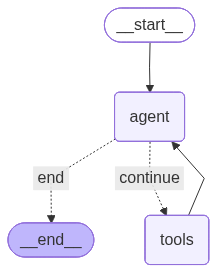

In [55]:
with suppress(Exception):
    display(Image(graph.get_graph().draw_mermaid_png()))


In [56]:
output = await graph.ainvoke(
    {
        'messages': [
            {
                'role': 'user',
                'content': 'which are the companies that were enforeced by these covernment agencies European Commission as well as the Federal Trade Commission ',
            }
        ],
        # 'user_name': user_name,
        # 'user_node_uuid': user_node_uuid,
    },
    config={'configurable': {'thread_id': uuid.uuid4().hex}},
)

Graph Retirieval [EntityEdge(uuid='f5f4b770-8a33-4117-909b-ab48ad89d608', group_id='political_monitoring_v2', source_node_uuid='2d85c6f4-002b-4a7d-b373-afc498d5c872', target_node_uuid='918a07a6-0682-4845-bede-94f80465f3f1', created_at=datetime.datetime(2025, 10, 16, 9, 21, 32, 481244, tzinfo=<UTC>), name='ENFORCES', fact='The European Commission enforces the Digital Markets Act to regulate tech giants.', fact_embedding=None, episodes=['80d9330e-c704-4d9d-b9ca-97245c58fc3b'], expired_at=datetime.datetime(2025, 10, 16, 9, 21, 34, 11922, tzinfo=<UTC>), valid_at=datetime.datetime(2025, 8, 26, 0, 0, tzinfo=<UTC>), invalid_at=datetime.datetime(2025, 9, 25, 0, 0, tzinfo=<UTC>), attributes={'fact_embedding': [-0.002751829568296671, -0.012120774947106838, -0.00036187353543937206, 0.015429333783686161, 0.010996714234352112, 0.056330323219299316, 0.031049545854330063, 0.030264822766184807, -0.016988173127174377, 0.009448477998375893, 0.05001012980937958, -0.021367771551012993, -0.0298406481742858

In [57]:
pprint(output)

{'messages': [HumanMessage(content='which are the companies that were enforeced by these covernment agencies European Commission as well as the Federal Trade Commission ', additional_kwargs={}, response_metadata={}, id='eeb99ea3-a35a-489c-88f4-564674a63ec1'),
              AIMessage(content='Information is insufficient to answer the query.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 432, 'total_tokens': 441, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_560af6e559', 'id': 'chatcmpl-CRccjXnScQ4J2DEhbFHD3Z8K8LxCE', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--20af7b77-459f-4685-a18e-5d770c5e6776-0', usage_metadata={'input_tokens': 432, 'output_tokens': 9, 'total

In [8]:
import os
print(os.getenv("LANGWATCH_API_KEY"))

None


In [11]:
import langwatch
import os
from openinference.instrumentation.langchain import LangChainInstrumentor
LANGWATCH_API_KEY="sk-lw-mYgXzWaermsnAMRQ5VRVSfRRYT8ebJnGfrWSdi2lKWkvijw2"
langwatch.setup(
    api_key="sk-lw-mYgXzWaermsnAMRQ5VRVSfRRYT8ebJnGfrWSdi2lKWkvijw2",
    instrumentors=[LangChainInstrumentor()] # Add the instrumentor for your LLM
)

2025-10-17 18:47:03,215 - langwatch.client - INFO - Registering atexit handler to flush tracer provider on exit
2025-10-17 18:47:03,216 - langwatch.client - WARNING - An existing global tracer provider was found. Attaching LangWatch exporter to the existing provider. Set `ignore_global_tracer_provider_override_warning=True` to suppress this warning.


In [13]:
import time
from dotenv import load_dotenv

load_dotenv()

import chainlit as cl

import langwatch

@langwatch.span(type="llm")
def generate(message: str):
    time.sleep(1)  # generating the message...

    generated_message = "Hello there! How can I help?"

    langwatch.get_current_span().update(model="custom_model")

    return generated_message


@cl.on_message
@langwatch.trace()
async def main(message: cl.Message):
    msg = cl.Message(
        content="",
    )

    langwatch.get_current_trace().update(
        metadata={"user_id": "123", "question_id": "456", "labels": ["some-label"]}
    )

    generated_message = generate(message.content)

    await msg.stream_token(generated_message)
    await msg.update()

2025-10-17 18:58:49 - Loaded .env file
2025-10-17 18:58:53 - Created default config file at /Users/mangeshkarangutkar/Documents/Agentic_AI/policiytracker-agentic-solution/agentic-solution-policiytracker/.chainlit/config.toml
2025-10-17 18:58:53 - Created default translation directory at /Users/mangeshkarangutkar/Documents/Agentic_AI/policiytracker-agentic-solution/agentic-solution-policiytracker/.chainlit/translations
2025-10-17 18:58:53 - Created default translation file at /Users/mangeshkarangutkar/Documents/Agentic_AI/policiytracker-agentic-solution/agentic-solution-policiytracker/.chainlit/translations/mr.json
2025-10-17 18:58:53 - Created default translation file at /Users/mangeshkarangutkar/Documents/Agentic_AI/policiytracker-agentic-solution/agentic-solution-policiytracker/.chainlit/translations/bn.json
2025-10-17 18:58:53 - Created default translation file at /Users/mangeshkarangutkar/Documents/Agentic_AI/policiytracker-agentic-solution/agentic-solution-policiytracker/.chainlit

In [12]:
!pip install chainlit

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pydantic_settings-2.11.0-py3-none-any.whl.metadata (3.4 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 14.3 MB/s  0:00:00 eta 0:00:01
Using cached pydantic_settings-2.11.0-py3-none-any.whl (48 kB)
  Created wheel for literalai: filename=literalai-0.1.201-py3-none-any.whl size=89157 sha256=111a405d29e66d8e5806e1b66f7dccb64deb44b7cfa949f3628c63bf30760eb6
  Stored in directory: /Users/mangeshkarangutkar/Library/Caches/pip/wheels/82/08/89/6cbb396706aec55a6dc2352136828887aa9c34effdbb7d971e
  Created wheel for syncer: filename=syncer-2.0.3-py2.py3-none-any.whl size=35

In [22]:
import os

import langwatch
from langwatch.attributes import AttributeKey
from langwatch.domain import SpanProcessingExcludeRule

# from community.instrumentors import OpenAIInstrumentor # Example instrumentor
from openinference.instrumentation.langchain import LangChainInstrumentor

from opentelemetry.sdk.trace import TracerProvider

# Example: Providing an existing TracerProvider
# existing_provider = TracerProvider()

# Example: Defining exclude rules
# exclude_rules = [
#     SpanProcessingExcludeRule(
#       field_name=["span_name"],
#       match_value="GET /health_check",
#       match_operation="exact_match"
#     ),
# ]

langwatch.setup(
    api_key="sk-lw-mYgXzWaermsnAMRQ5VRVSfRRYT8ebJnGfrWSdi2lKWkvijw2",
    endpoint_url="http://localhost:5560", # Optional: Defaults to env var or cloud
    base_attributes={
      AttributeKey.ServiceName: "my-awesome-service",
      AttributeKey.ServiceVersion: "1.2.3",
      # Add other custom attributes here
    },
    instrumentors=[LangChainInstrumentor()], # Optional: List of instrumentors that conform to the `Instrumentor` protocol
    # tracer_provider=existing_provider, # Optional: Provide your own TracerProvider
    debug=True, # Optional: Enable debug logging
    disable_sending=False, # Optional: Disable sending traces
    flush_on_exit=True, # Optional: Flush traces on exit (default: True)
    # span_exclude_rules=exclude_rules, # Optional: Rules to exclude spans
    ignore_global_tracer_provider_override_warning=False # Optional: Silence warning if global provider exists
)

# Your application code...

TypeError: setup() got an unexpected keyword argument 'disable_sending'

In [11]:
import os 
# from dotenv import load_dotenv
# load_dotenv()

print(os.environ.get('LANGWATCH_ENDPOINT'))

http://localhost:5560


In [17]:
import langfuse